In [1]:
######################### estimate the area under the arc using FTS in one dimension

import numpy as np
import matplotlib.pyplot as plt


## function we want to find its area
def Arc_function(x):
    x = np.asarray(x)
    return np.sqrt(np.clip(1 - x**2, 0, None))


## FTS in one dimension algorithm
rng = np.random.default_rng(42)
num_samples = int(1e4)

# 1. Sample X ~ Unif[-1, 1] and U ~ Unif[0, 1]
x = rng.uniform(-1, 1, num_samples)
u = rng.uniform(0, 1, num_samples)


# 2. Accept if u < f(x)
accept = u < Arc_function(x)
accepted_X_samples = x[accept]
accepted_U_samples = u[accept]
rejected_X_samples = x[~accept]
rejected_U_samples = u[~accept]

# Estimate the area using Monte Carlo
p_accept = accept.mean()
area_under_the_arc = 2*p_accept

print(f"Monte Carlo estimate: {area_under_the_arc:.4f}")
print(f"True area: {np.pi/2:.4f}")


Monte Carlo estimate: 1.5640
True area: 1.5708


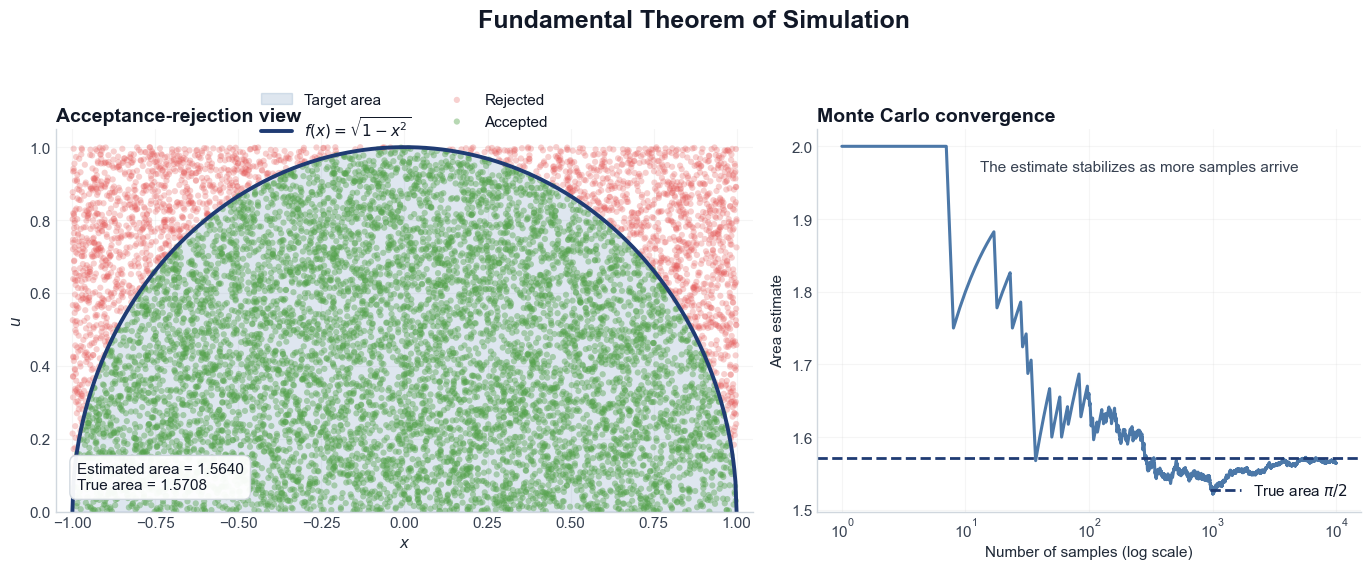

In [5]:
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": "#D0D7DE",
    "axes.labelcolor": "#1F2937",
    "text.color": "#111827",
    "xtick.color": "#374151",
    "ytick.color": "#374151",
    "font.size": 11,
})

x_grid = np.linspace(-1, 1, 600)
y_grid = Arc_function(x_grid)
running_area = 2 * np.cumsum(accept) / np.arange(1, num_samples + 1)
true_area = np.pi / 2

fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 5.5),
    gridspec_kw={"width_ratios": [1.18, 0.92]},
)

fig.suptitle(
    "Fundamental Theorem of Simulation",
    fontsize=18,
    fontweight="bold",
    y=1.03,
)

# Left panel: acceptance-rejection picture
ax = axes[0]
ax.fill_between(x_grid, 0, y_grid, color="#4C78A8", alpha=0.18, label="Target area")
ax.plot(x_grid, y_grid, color="#1F3B73", lw=2.8, label=r"$f(x)=\sqrt{1-x^2}$")
ax.scatter(
    rejected_X_samples,
    rejected_U_samples,
    s=20,
    color="#E45756",
    alpha=0.28,
    edgecolors="none",
    label="Rejected",
)
ax.scatter(
    accepted_X_samples,
    accepted_U_samples,
    s=20,
    color="#54A24B",
    alpha=0.42,
    edgecolors="none",
    label="Accepted",
)
ax.set_title("Acceptance-rejection view", loc="left", fontsize=14, fontweight="bold")
ax.set_xlabel("$x$")
ax.set_ylabel("$u$")
ax.set_xlim(-1.05, 1.05)
ax.set_ylim(0, 1.05)
ax.legend(frameon=False, ncol=2, loc="upper center", bbox_to_anchor=(0.5, 1.13))
ax.text(
    0.03,
    0.05,
    f"Estimated area = {area_under_the_arc:.4f}\nTrue area = {true_area:.4f}",
    transform=ax.transAxes,
    ha="left",
    va="bottom",
    fontsize=11,
    bbox={
        "boxstyle": "round,pad=0.45",
        "facecolor": "white",
        "edgecolor": "#D0D7DE",
        "alpha": 0.95,
    },
)

# Right panel: convergence curve
ax2 = axes[1]
ax2.plot(np.arange(1, num_samples + 1), running_area, color="#4C78A8", lw=2.2)
ax2.axhline(true_area, color="#1F3B73", ls="--", lw=2, label=r"True area $\pi/2$")
ax2.set_xscale("log")
ax2.set_xlabel("Number of samples (log scale)")
ax2.set_ylabel("Area estimate")
ax2.set_title("Monte Carlo convergence", loc="left", fontsize=14, fontweight="bold")
ax2.legend(frameon=False, loc="lower right")
ax2.text(
    0.3,
    0.92,
    "The estimate stabilizes as more samples arrive",
    transform=ax2.transAxes,
    fontsize=11,
    color="#374151",
    va="top",
)

for ax_i in axes:
    ax_i.spines["top"].set_visible(False)
    ax_i.spines["right"].set_visible(False)
    ax_i.grid(True, alpha=0.18)

fig.tight_layout()

fig.savefig("FTS_area_estimate.pdf", bbox_inches="tight", dpi=600)
